In [11]:
import SimDAT2D.SimDAT2D_MDK as sim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import IsoDAT2D.IsoDAT2D_MDK as iso
from PIL import Image
import pyFAI, fabio
from pyFAI.gui import jupyter
import pyFAI
import os
import matplotlib.pyplot as plt
from tifffile import imread
from SimDAT2D import masking
import pyFAI.azimuthalIntegrator as AI

In [12]:
# # to reload any iterative changes to the code, uncomment the following lines:
import importlib
sim = importlib.reload(sim)
iso = importlib.reload(iso)

Select calibrant:
1. AgBh
2. Al
3. alpha_Al2O3
4. Au
5. C14H30O
6. CeO2
7. Cr2O3
8. cristobaltite
9. CrOx
10. CuO
11. hydrocerussite
12. LaB6
13. LaB6_SRM660a
14. LaB6_SRM660b
15. LaB6_SRM660c
16. mock
17. NaCl
18. Ni
19. PBBA
20. Pt
21. quartz
22. Si
23. Si_SRM640
24. Si_SRM640a
25. Si_SRM640b
26. Si_SRM640c
27. Si_SRM640d
28. Si_SRM640e
29. TiO2
30. ZnO
Ni


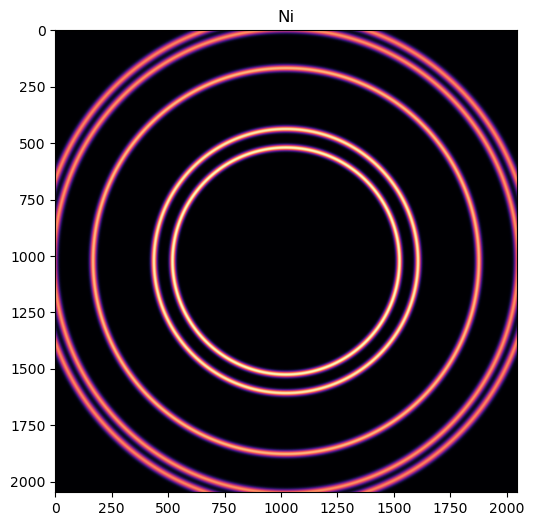

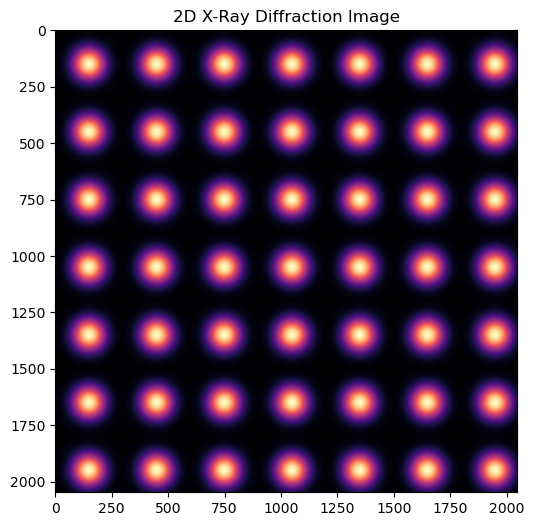

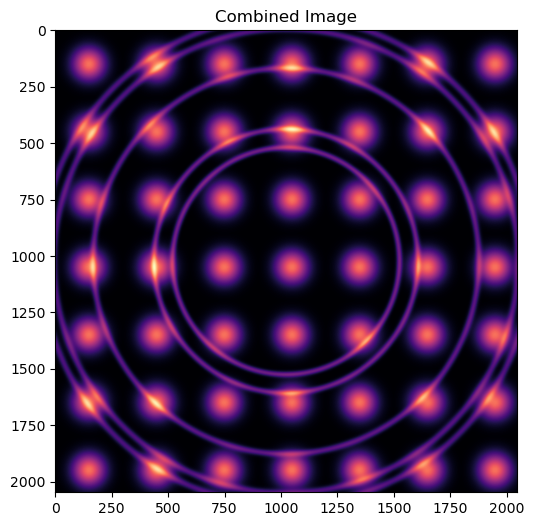

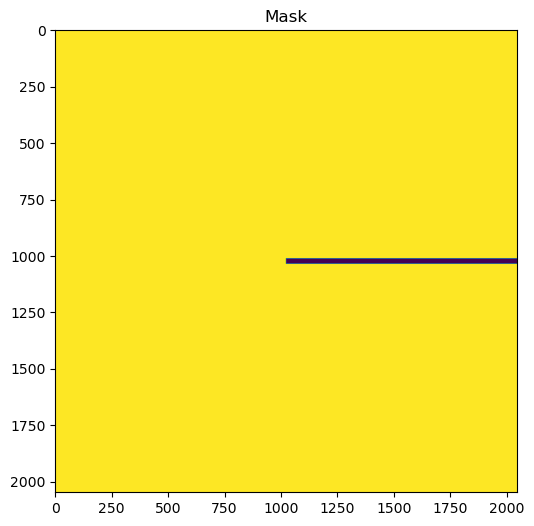

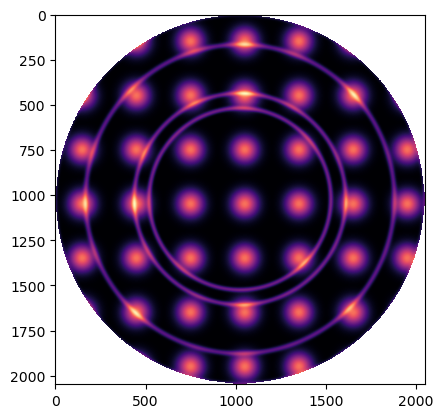

In [3]:
thin_film = sim.create_isotropic(.4, .5e-10, cmap = 'magma')
substrate = sim.create_anisotropic(25, 50, 300, 300, cmap = 'magma')
film_on_substrate = sim.combine_image(thin_film, substrate*2, cmap= 'magma')
mask12 = sim.create_mask(thin_film, 12)
film_on_substrate_circle = sim.mask_circle_nan_edge(film_on_substrate)
plt.imshow(film_on_substrate_circle, cmap = 'magma')

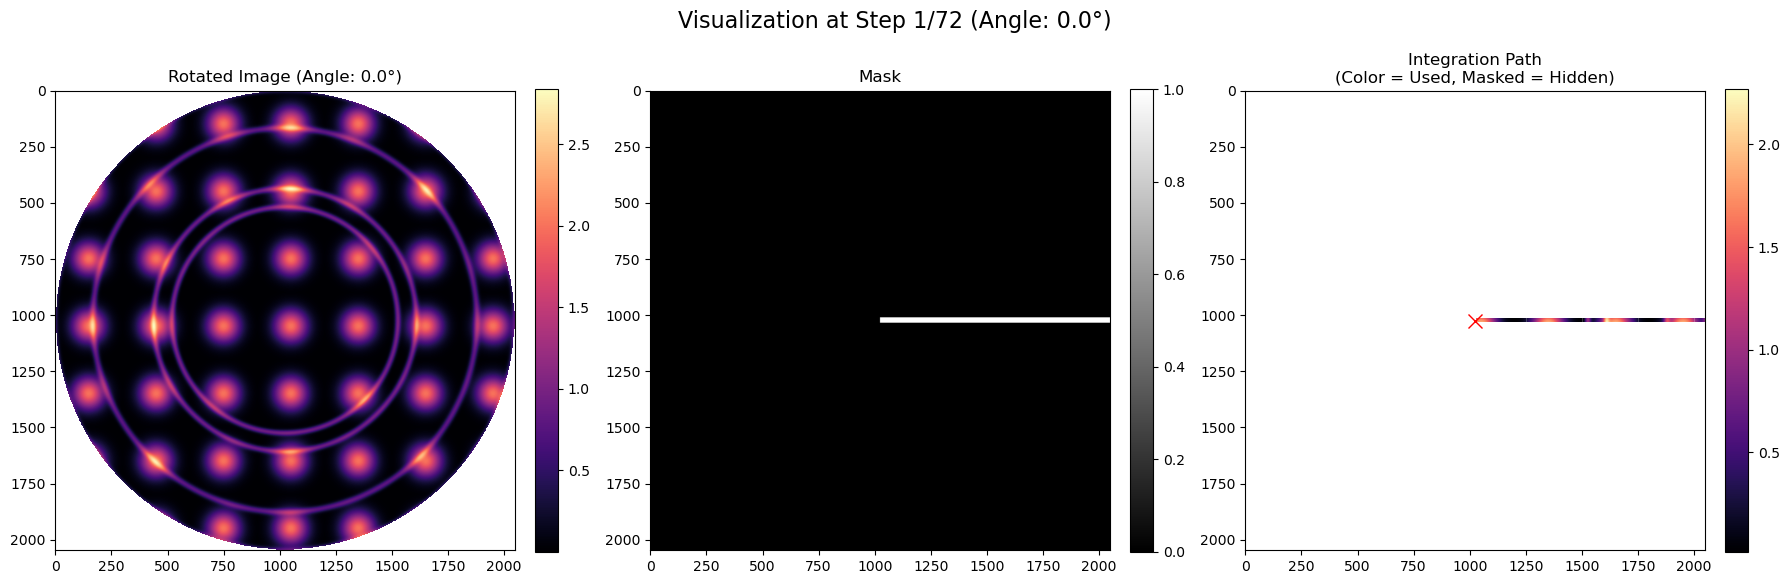

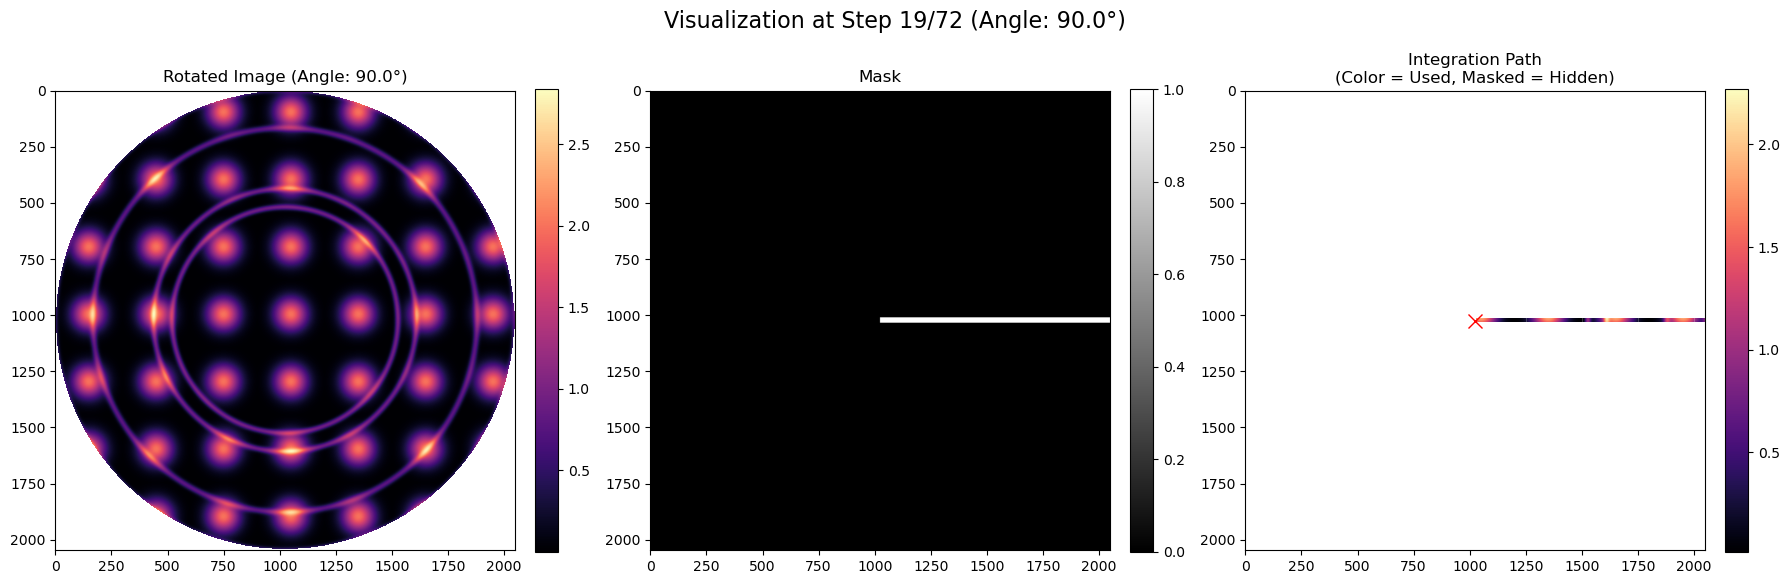

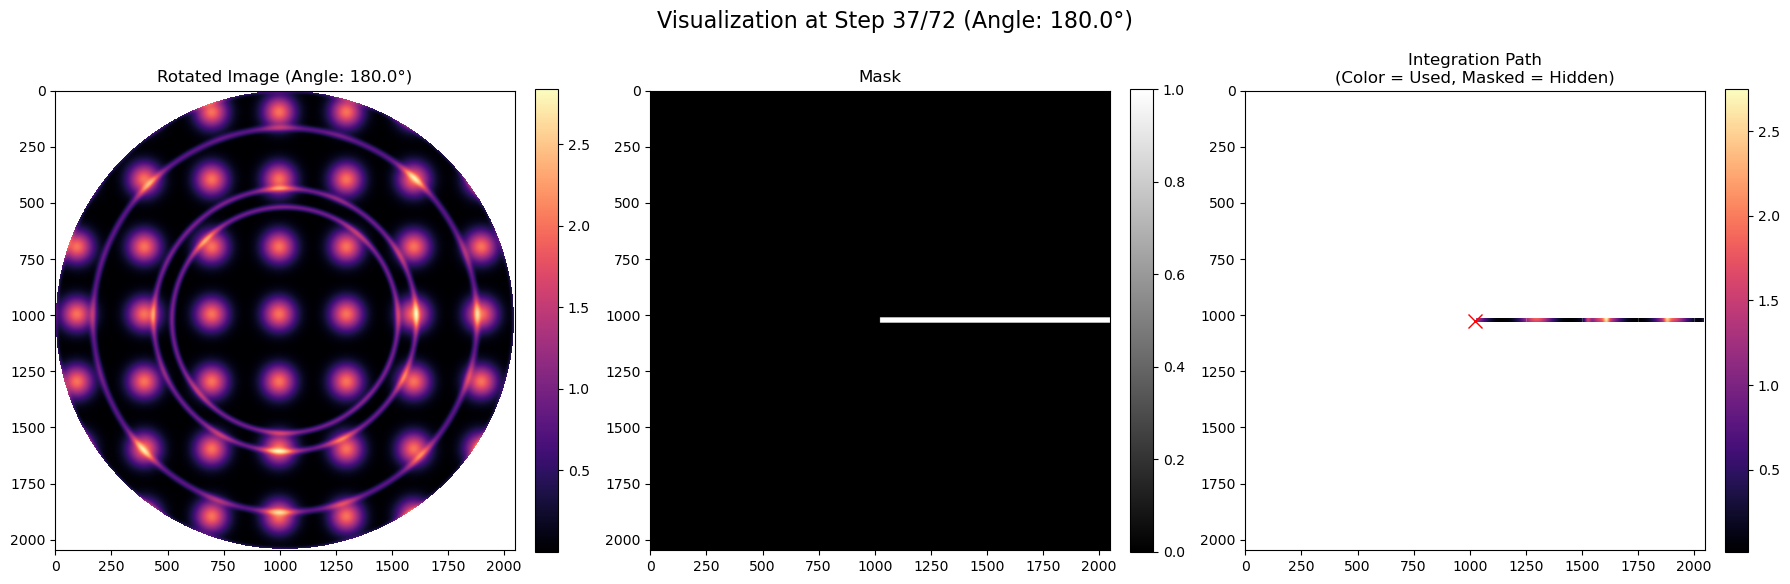

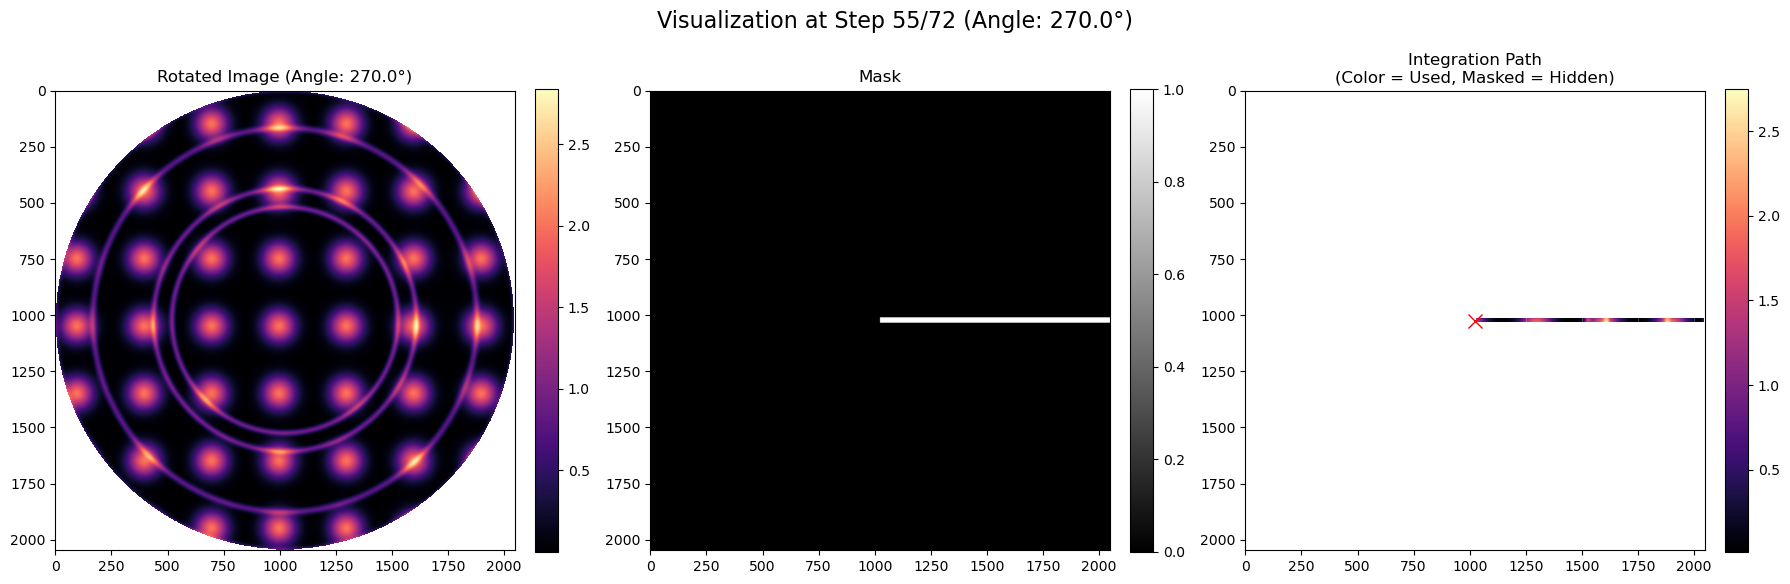

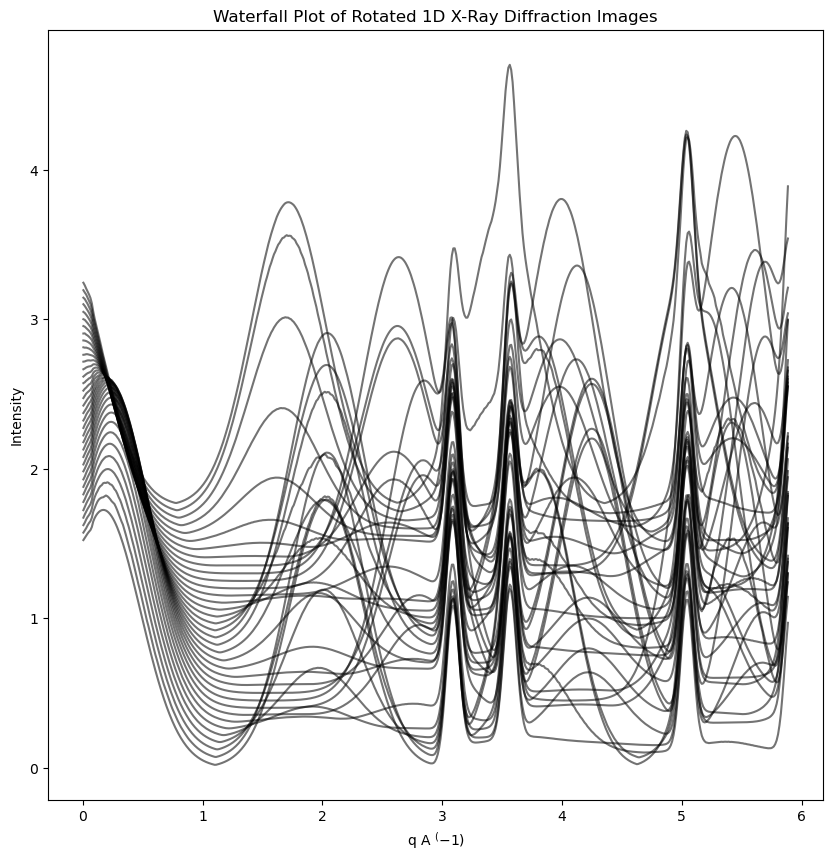

In [4]:
q, label1d_data = sim.rotate_and_integrate_printout(film_on_substrate_circle, 5, .4, .5e-10, resolution = 500, mask = mask12, vis_interval = 18)

Starting NMF algorithm with the following parameters:

Max components: 10
Max iterations: 600
Init: random
Solver: cd
Tolerance: 0.0001
Patience: 5
Random
Random initializers completed
Continuing with best run parameters that are init: nndsvda, solver: mu, tol: 1e-05
Run with 1 components has been completed
Run with 2 components has been completed
Run with 3 components has been completed
Run with 4 components has been completed
Run with 5 components has been completed
Run with 6 components has been completed
Run with 7 components has been completed
Run with 8 components has been completed
Run with 9 components has been completed
Run with 10 components has been completed


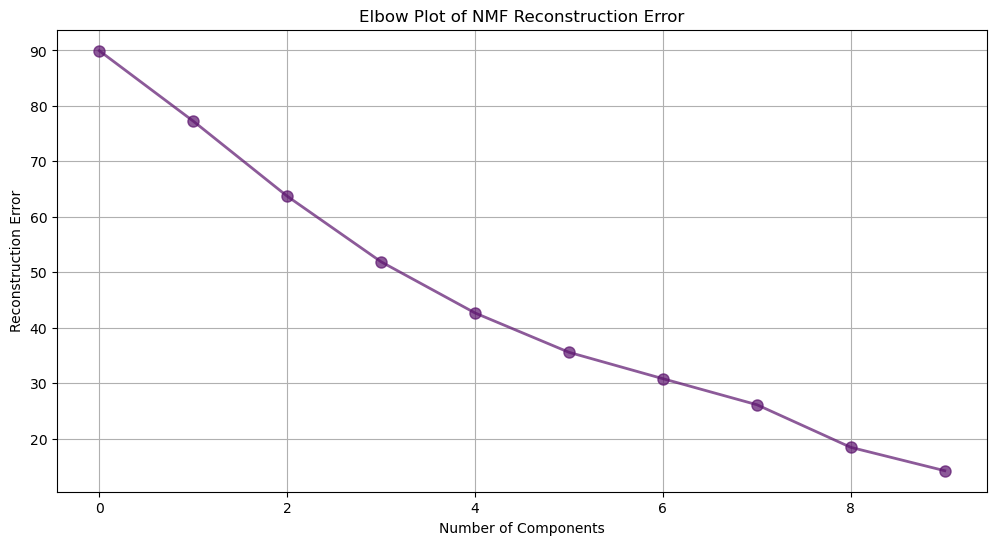

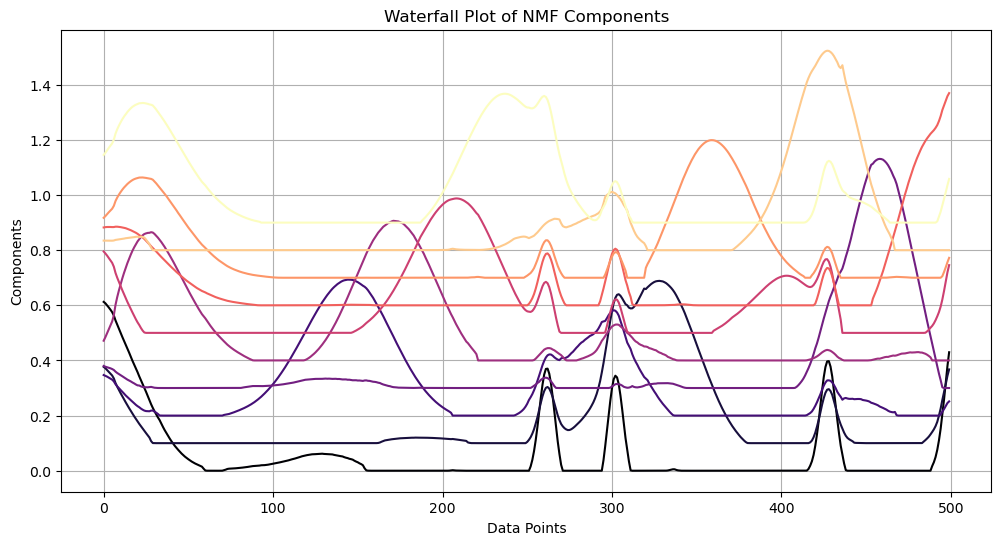

The best number of components is 10


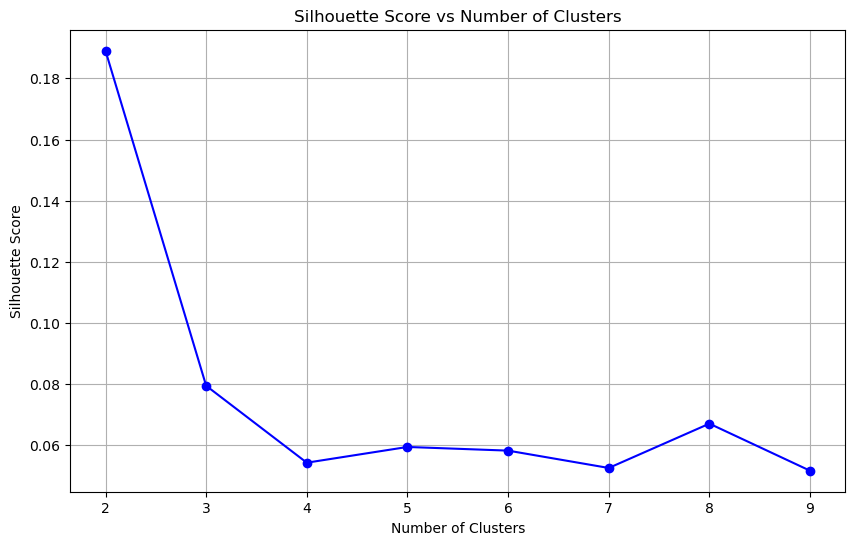

Optimal number of clusters: 2
Average silhouette score: 0.189


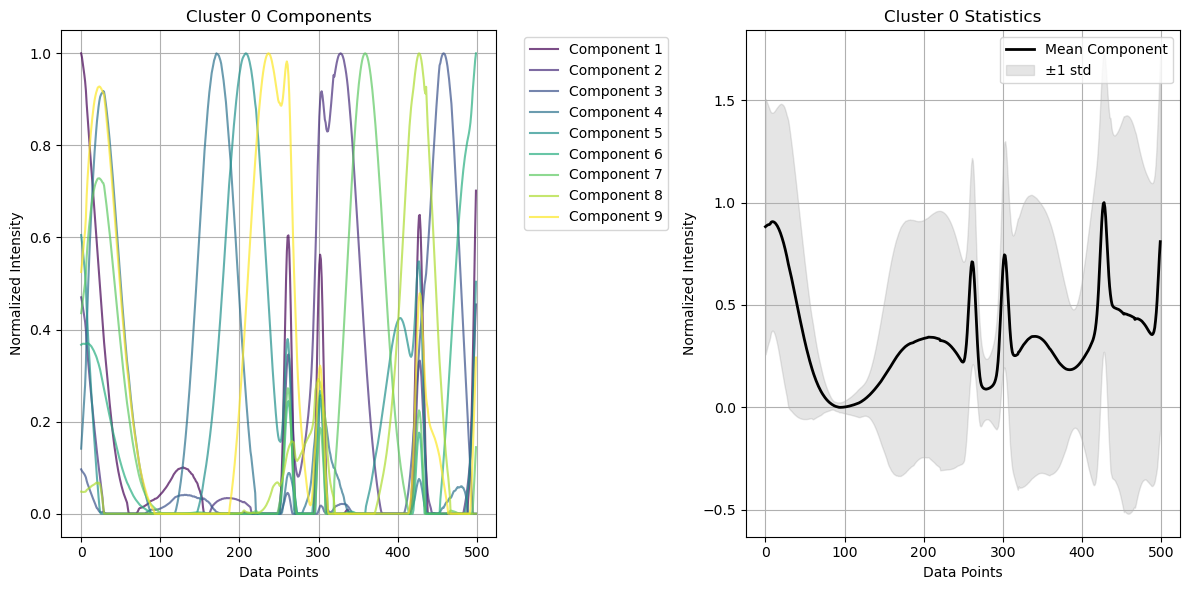

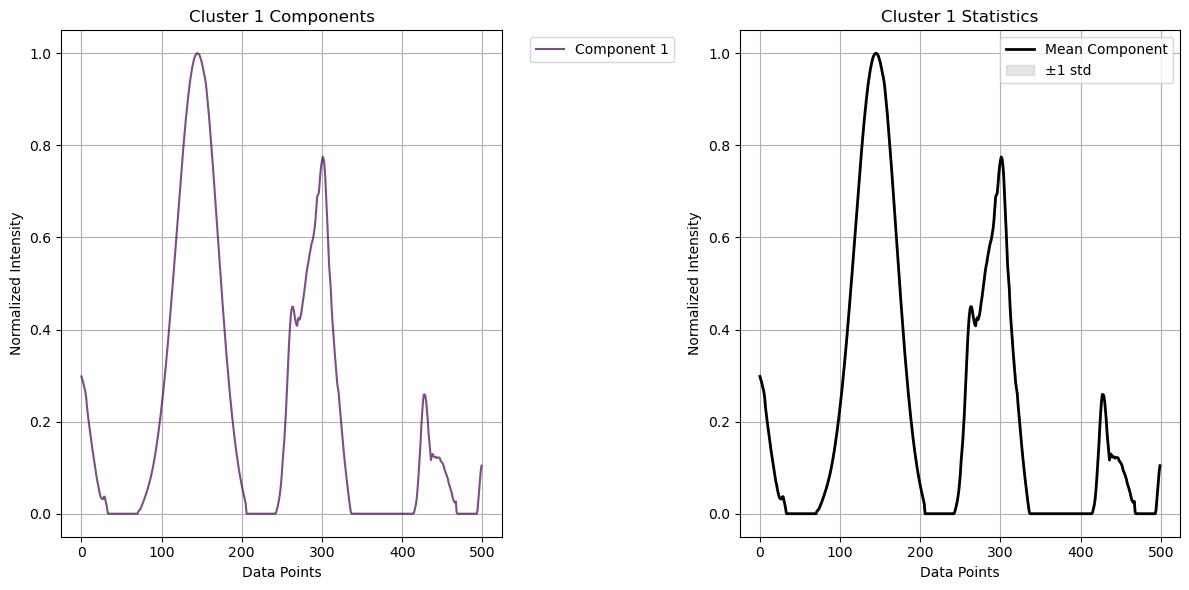

In [13]:
# Run NMF and cluster with automatic cluster number selection
W, H, err, clusters = iso.run_sklearn_nmf_and_agg_cluster(
    label1d_data,
    max_components=10,  # Adjust based on your data
    cluster_matrix='W'  # or 'H' depending on which matrix you want to cluster
)

Starting NMF algorithm with the following parameters:

Max components: 10
Max iterations: 600
Init: random
Solver: cd
Tolerance: 0.0001
Patience: 5
Random
Random initializers completed
Continuing with best run parameters that are init: nndsvda, solver: cd, tol: 1e-06
Run with 1 components has been completed
Run with 2 components has been completed
Run with 3 components has been completed
Run with 4 components has been completed
Run with 5 components has been completed
Run with 6 components has been completed
Run with 7 components has been completed
Run with 8 components has been completed
Run with 9 components has been completed
Run with 10 components has been completed


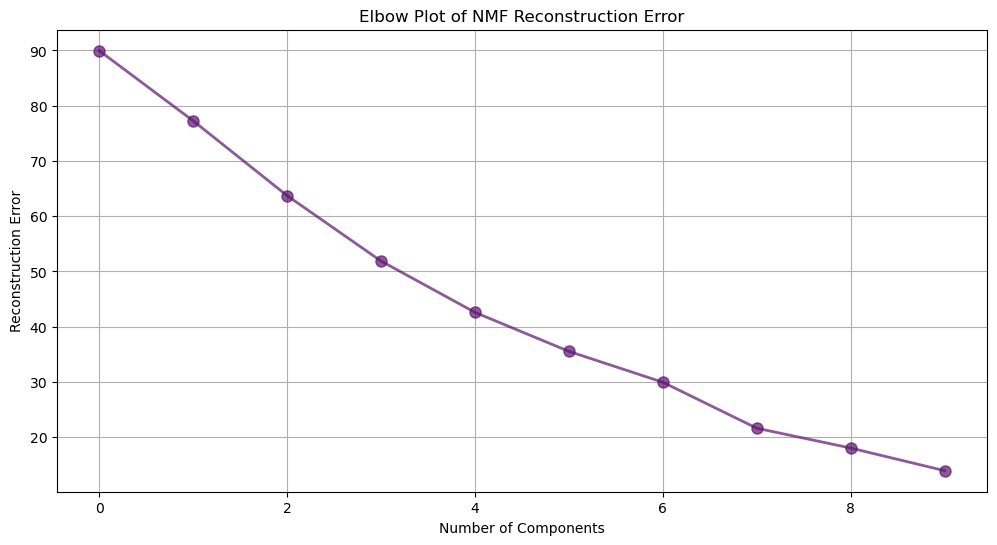

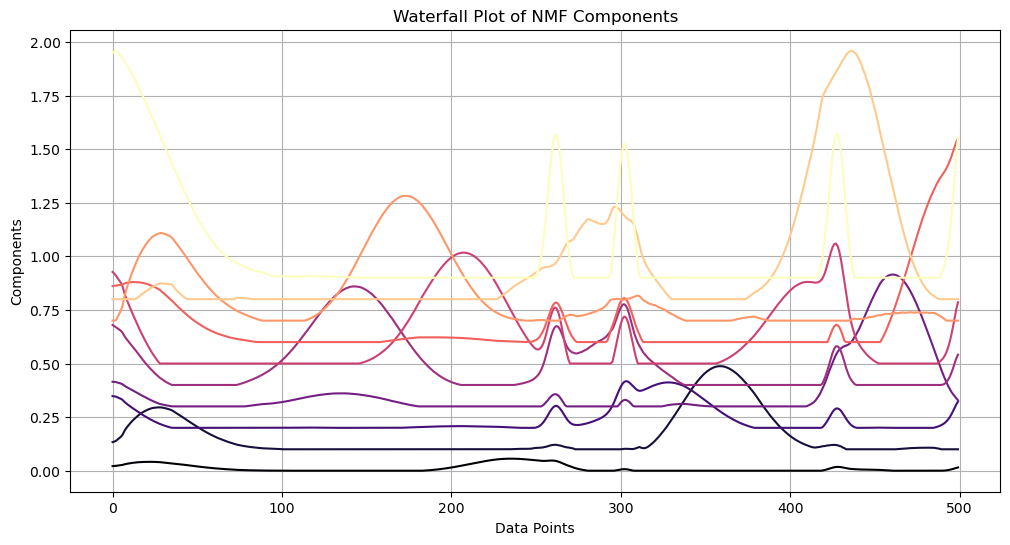

The best number of components is 10


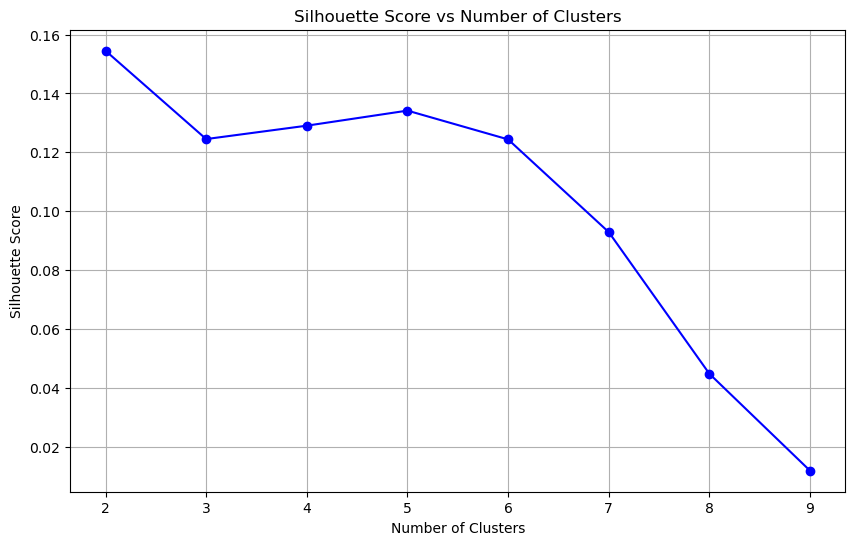

Optimal number of clusters: 2
Average silhouette score: 0.155


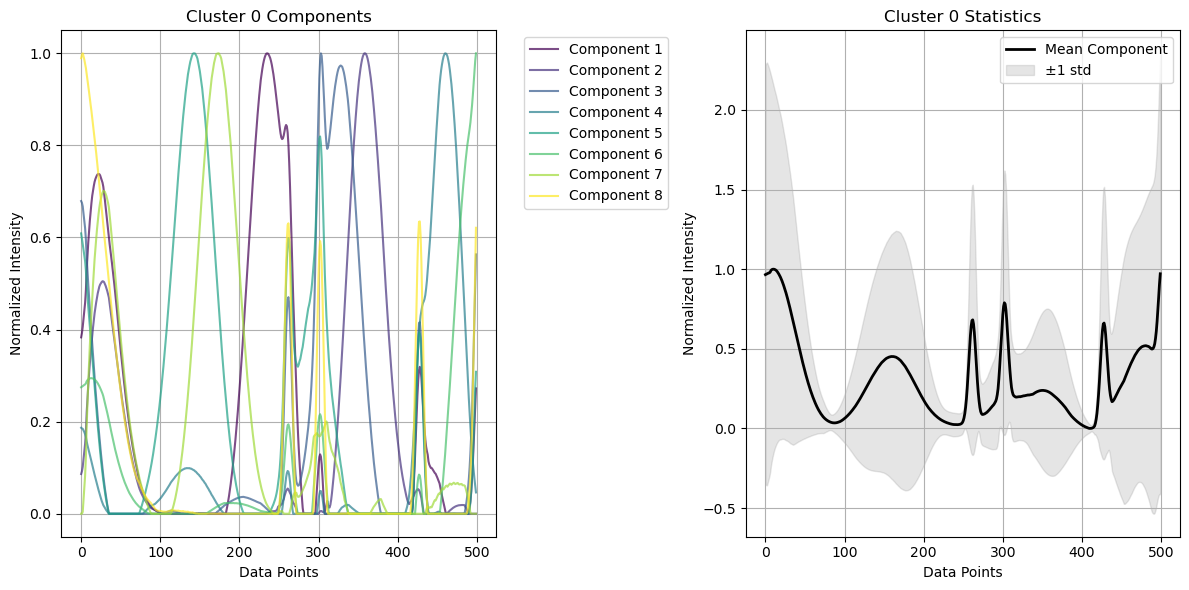

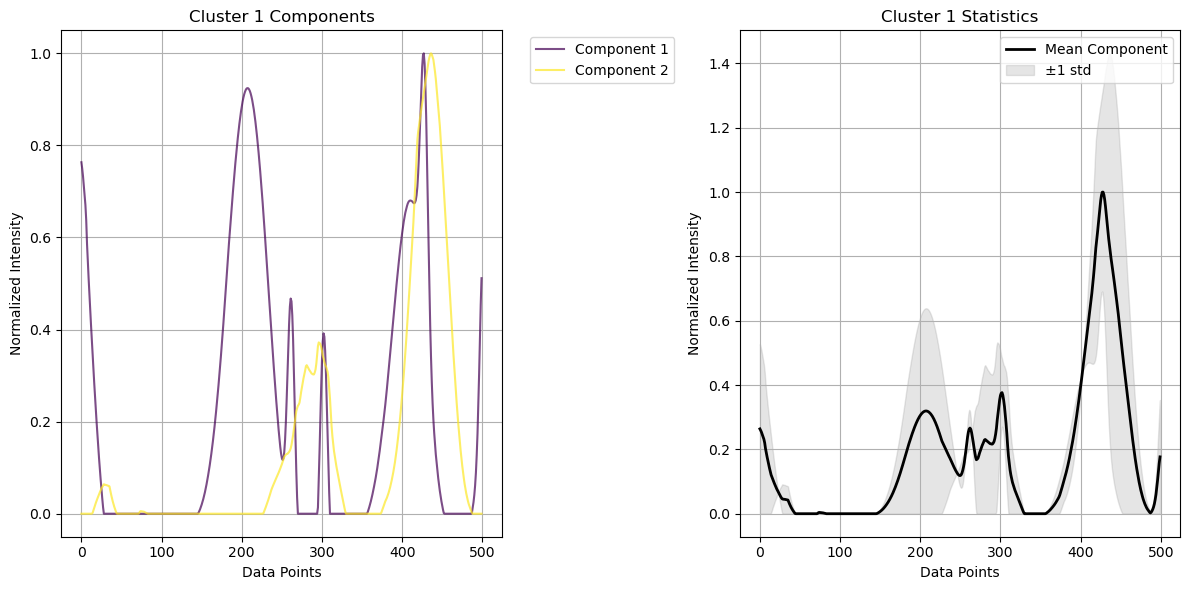

In [15]:
# For automatic cluster selection:
W, H, err, clusters = iso.run_sklearn_nmf_and_agg_cluster(
    label1d_data,
    max_components=10,
    n_clusters=None  # Will automatically select optimal number
)